In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

### *(a)* Fixed points


Along with the trivial fixed point $x^* = 0$, for $x^* \neq 0$ we have.
\begin{align*}
    x^* &= rx^*(1 - x^*) \\
    1 &= r(1- x^*) \\
    x^* &= 1 -\frac{1}{r}
\end{align*}

### *(b)* Stability

The derivative of the logistic map is $f'(x_n) = r(1 - 2x_n)$, so for the fixed point at $x^* = 0$ we have (noting that $r$ must be positive):
\begin{alignat*}{2}
    -1 &< r &< 1 \\
    0 &< r &< 1
\end{alignat*}
And for the $x^* = 1 - \frac{1}{r}$ fixed point,
\begin{alignat*}{2}
    -1 &< r\left(1 - 2 + \frac{2}{r}\right) &< 1 \\
    -1 &< \qquad 2 - r &< 1 \\
\end{alignat*}

So we have $r < 3$ from the left inequality and $r  > 1$ from the right. The nontrivial fixed-point loses stability at $r = 3$.

### *(c)* Two-cycle

We have $f(f(x)) = x$, where $f(f(x))$ is:
\begin{align*}
    r\left[rx(1-x)\right](1 - \left[rx(1-x)\right]) &= r^2x\left(1 - x\right) \left(1 - rx + rx^2\right)
\end{align*}
And setting that equal to $x$ we get:
\begin{align*}
    r^2x\left(1 - x\right) \left(1 - rx + rx^2\right) &= x \\
    r^2\left(1 - rx + rx^2 - x + rx^2 - rx^3\right) &= 1 \\
    -r^3 x^3 + 2r^3 x^2 - r^2(1+r)x + (r^2 - 1) &= 0
\end{align*}

Now, the goal is to divide out the factor from our fixed point $(x - \frac{r-1}{r})$. I don't feel like trying to format that, but I did 
the synthetic division on a white board in the library (mostly to see if I remembered how to do it; I did not but Google is a wonderful thing).
Anyways, the result post-division is:
\begin{align*}
    -r^3x^2 + r^2(r-1)x - r(r+1) &= 0 \\
    x^2 - \frac{r-1}{r}x + \frac{r+1}{r^2} &= 0
\end{align*}

### *(d)* Bifurcation diagram.

I'm actually doing this homework after doing the take-home exam whoops so I'm just gonna copy past that code.

In [20]:
def logistic(x,r):
    return r*x*(1-x)

def dynamical_sys(x0,f,p,warmup=1000,keep=200):
    x = x0

    for i in range(warmup):
        x = f(x,p)

    x_to_keep = np.zeros(shape=(keep,))

    for i in range(keep):
        x_to_keep[i] = f(x,p)
        x = x_to_keep[i]
    
    return x_to_keep

In [21]:
keep = 200
r_ls = np.arange(2.5,4,0.0002)
x0 = 0.25

# store results in a matrix where each row is a value of r
bifurcation_matr = np.zeros(shape=(len(r_ls), keep))

for i in range(len(r_ls)):
    bifurcation_matr[i] = dynamical_sys(x0, logistic, r_ls[i])

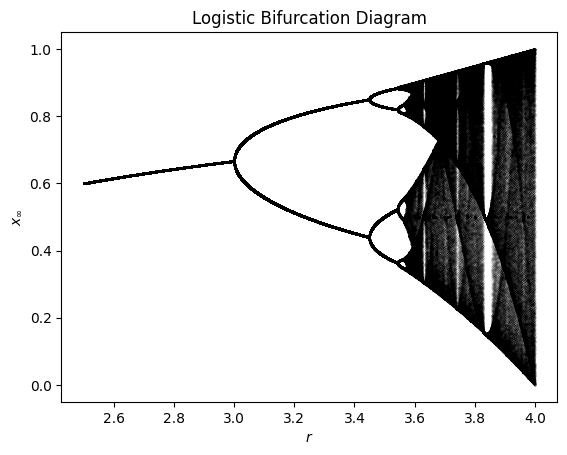

In [22]:
r_vals = np.repeat(r_ls, keep)
x_vals = bifurcation_matr.flatten()

plt.scatter(r_vals, x_vals, s=0.001, c='black')
plt.title('Logistic Bifurcation Diagram')
plt.xlabel(r'$r$')
plt.ylabel(r'$x_\infty$')
plt.show()

### *(e)* Lyapunov

In [23]:
def lyapunov(r, xs):
    N = len(xs)
    summ = 0
    for i in range(N):
        summ += np.log(np.abs(r*(1-2*xs[i])))
    return summ / N

lyapunovs = []
for i in range(len(r_ls)):
    lyapunovs.append(lyapunov(r_ls[i], bifurcation_matr[i]))

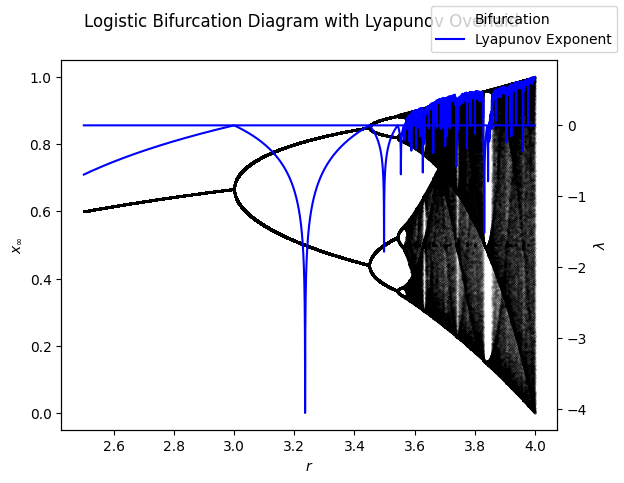

In [24]:
fig, ax1 = plt.subplots()
fig.suptitle('Logistic Bifurcation Diagram with Lyapunov Overlaid')
ax2 = ax1.twinx() 
ax1.scatter(r_vals, x_vals, s=0.001, c='black', label="Bifurcation")
ax2.plot(r_ls, np.repeat(0, len(r_ls)), color="blue")
ax2.plot(r_ls, lyapunovs, label="Lyapunov Exponent", color="blue")

ax1.set_ylabel(r'$x_\infty$')
ax1.set_xlabel(r'$r$')
ax2.set_ylabel(r'$\lambda$')

fig.legend()

plt.show()

So we do indeed see negative $\lambda$ in the periodic regions and positive in the chaotic regions. $\lambda = 0$ occurs precisely at the points of period doubling.

# Problem 2: Damped Driven Pendulum

### *(a)* Small oscillation steady state

\begin{align*}
    \ddot\theta + \gamma\dot\theta + \omega_0^2\theta = A\cos(\omega_d t)
\end{align*}

Assuming a solution of the form $\theta(t) = \theta_\text{max} \left[B\cos(\omega_d t) + C\sin(\omega_d t)\right]$ (oscillatory with the same frequency as the driving force, but not necessarily in phase), we can take a couple derivatives to find $\dot\theta(t)= -\omega_d\theta_\text{max} \left[B\sin(\omega_d t) - C\cos(\omega_d t)\right]$ and $\ddot\theta(t) = -\omega_d^2\theta_\text{max} \left[B\cos(\omega_d t) + C\sin(\omega_d t)\right]$. Substituting those in,

\begin{align*}
    (\omega_0^2-\omega_d^2)\theta_\text{max} \left[B\cos(\omega_d t) + C\sin(\omega_d t)\right]
    +\gamma\omega_d\theta_\text{max} \left[-B\sin(\omega_d t) + C\cos(\omega_d t)\right]
    &=
    A\cos(\omega_d t)
\end{align*}

\begin{align*}
    \sin(\omega_d t) \left[C (\omega_0^2-\omega_d^2)\theta_\text{max} - B\gamma\omega_d\theta_\text{max}\right] 
    &= 
    \cos(\omega_d t) \left[A - B(\omega_0^2 - \omega_d^2)\theta_\text{max} - C\gamma\omega_d\theta_\text{max}\right]
\end{align*}

Matching coefficients, we need each term in brackets to be yero (since for example the LHS has no cos terms, so the cos terms on the right must be zero and vice verse for sins):
\begin{align*}
    C (\omega_0^2-\omega_d^2)\theta_\text{max} - B\gamma\omega_d\theta_\text{max} &= 0 \\
    B &= C \frac{\omega_0^2-\omega_d^2}{\gamma\omega_d}
\end{align*}

It's common to set $B^2 + C^2 = 1$, so this becomes:
\begin{align*}
    C^2\left(\frac{(\omega_0^2-\omega_d^2)^2}{(\gamma\omega_d)^2} + 1\right) &= 1 \\
    C &= \left[1+\frac{(\omega_0^2-\omega_d^2)^2}{(\gamma\omega_d)^2}\right]^{-1/2}
\end{align*}

Then matching the cos terms.

\begin{align*}
    A - B(\omega_0^2 - \omega_d^2)\theta_\text{max} - C\gamma\omega_d\theta_\text{max} &= 0 \\
    A &= \theta_\text{max} \left[B(\omega_0^2 - \omega_d^2) + C\gamma\omega_d\right] \\
    &= C\theta_\text{max} \left[\frac{(\omega_0^2 - \omega_d^2)^2}{\gamma\omega_d} + \gamma\omega_d \right] \\
    &= C\gamma\omega_d\theta_\text{max} \left[1 + \frac{(\omega_0^2 - \omega_d^2)^2}{(\gamma\omega_d)^2}\right] \\
    &= \gamma\omega_d\theta_\text{max} \left[1 + \frac{(\omega_0^2 - \omega_d^2)^2}{(\gamma\omega_d)^2}\right]^{1/2} \\
    A &=\theta_\text{max} \left[\left(\gamma\omega_d\right)^2 + (\omega_0^2 - \omega_d^2)^2\right]^{1/2}
\end{align*}
Thus, at the end of the day, we have

\begin{align*}
    \theta_\text{max} &= \frac{A}{\sqrt{(\gamma\omega_d)^2 + (\omega_0^2 - \omega_d^2)^2}}
\end{align*}


For $\omega_0 = 1$, $\gamma = 0.5$, and $\omega_d = \frac{2}{3}$, we can find the $A$ that results in $\theta_\text{max} = \frac{\pi}{4}$ as:

In [25]:
omega_0 = 1
gamma = 0.5
omega_d = 2/3

theta_max = np.pi / 4

A = theta_max * np.sqrt((gamma*omega_d)**2 + (omega_0**2 - omega_d**2)**2) 
print(A)

0.5088465454522634


### *(b)* Poincare Sections

In [26]:
from scipy.integrate import solve_ivp

The second order ODE $\ddot\theta = - \gamma\dot\theta - \omega_0^2\sin\theta = A\cos(\omega_d t)$ can be written as a system of first order equations using $y_1 = \theta$ and $y_2 = \dot\theta$:

\begin{align*}
    \frac{d}{dt}
    \begin{bmatrix}
        y_1 \\
        y_2
    \end{bmatrix}
    =
    \begin{bmatrix}
        y_2 \\
        A\cos(\omega_d t) - \gamma y_2 - \omega_0^2 \sin(y_1)
    \end{bmatrix}
\end{align*}

In [74]:
def ddp(t, y, A, omega_d = omega_d, omega_0 = omega_0, gamma = gamma):
    theta, d_theta = y

    dd_theta = A*np.cos(omega_d * t) - gamma * d_theta - omega_0**2 * np.sin(theta)

    return [d_theta, dd_theta]

In [116]:
driving_T = (2*np.pi)/omega_d
t0 = 0

start = 100
end = 500
t_warm = start*driving_T
tf = end*driving_T
num_t = 1*(end - start + 1)

# we want to plot at integer multiples of driving frequency, 100 through 500
t_eval = np.linspace(t_warm, tf, num_t)

In [145]:
y0 = [0,0]

A_1 = 0.5
A_2 = 1.0
A_3 = 1.15
A_4 = 1.35

sol1 = solve_ivp(ddp, [t0,tf], y0, args=[A_1], t_eval=t_eval)
sol2 = solve_ivp(ddp, [t0,tf], y0, args=[A_2], t_eval=t_eval)
sol3 = solve_ivp(ddp, [t0,tf], y0, args=[A_3], t_eval=t_eval)
sol4 = solve_ivp(ddp, [t0,tf], y0, args=[A_4], t_eval=t_eval)

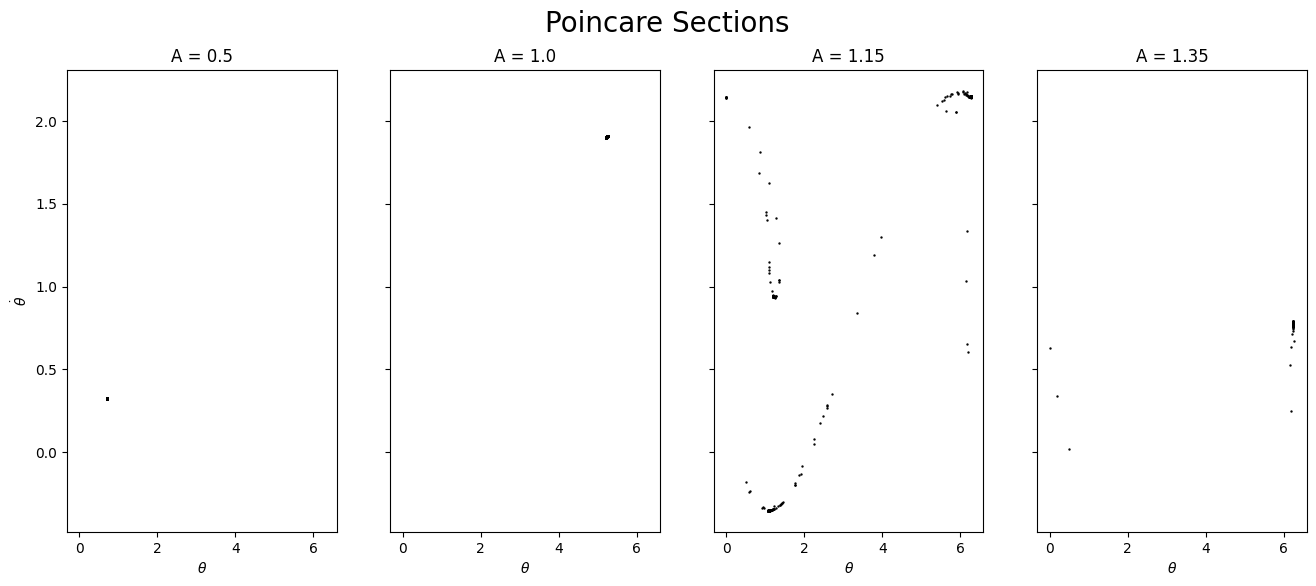

In [147]:
fig, ax = plt.subplots(1,4, figsize=(16,6), sharey=True, sharex=True)

fig.suptitle("Poincare Sections",fontsize=20)

ax[0].set_title("A = 0.5")
ax[1].set_title("A = 1.0")
ax[2].set_title("A = 1.15")
ax[3].set_title("A = 1.35")

ax[0].set_ylabel(r"$\dot\theta$")
ax[0].set_xlabel(r"$\theta$")
ax[1].set_xlabel(r"$\theta$")
ax[2].set_xlabel(r"$\theta$")
ax[3].set_xlabel(r"$\theta$")

ax[0].scatter(np.mod(sol1.y[0], 2*np.pi), sol1.y[1], s=0.5, c='black')
ax[1].scatter(np.mod(sol2.y[0], 2*np.pi), sol2.y[1], s=0.5, c='black')
ax[2].scatter(np.mod(sol3.y[0], 2*np.pi), sol3.y[1], s=0.5, c='black')
ax[3].scatter(np.mod(sol4.y[0], 2*np.pi), sol4.y[1], s=0.5, c='black')

So we basically see one point in the periodic regime (which makes sense, only having one point in the periodic cross section), then that point gets bigger near period doubling indicating variation from that one point in phase space. As it gets more chaotic, it spreads out more and more in phase space, but $A=1.35$ is noticably not all too chaotic. A periodic window, as I learned in a later part of the problem.

### *(c)* Bifurcation Diagram

In [148]:
A_ls = np.linspace(0.5, 1.5, 100)

bifurcation_matr = np.zeros(shape=(len(A_ls), len(sol1.y[0])))

i = 0
for A in A_ls: 
    bifurcation_matr[i] = solve_ivp(ddp, [t0,tf], y0, args=[A], t_eval=t_eval).y[0]
    i += 1

In [150]:
A_vals = np.repeat(A_ls, len(bifurcation_matr[0]))
theta_vals = bifurcation_matr.flatten()

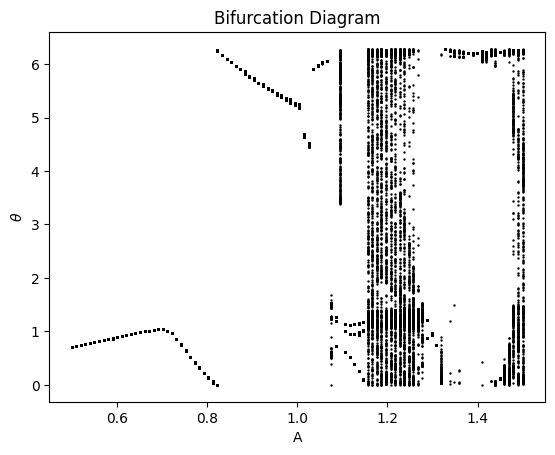

In [151]:
plt.scatter(A_vals, np.mod(theta_vals, 2*np.pi), s=0.5, c='black')
plt.title("Bifurcation Diagram")
plt.xlabel("A")
plt.ylabel(r"$\theta$")
plt.show()

The first period doubling bifurcation occurs around $A=1$, while chaos occurs later around $A=1.15$, and there's a periodic looking window around $A \in \{1.25,1.3\}$

### *(d)* Chaos

(i) and (ii)

In [ ]:
driving_T = (2*np.pi)/omega_d
t0 = 0
tf = 100
num_t = 1000
t_eval = np.linspace(t0, tf, num_t)

In [179]:
A_chaotic = 1.2

y0_a = [0,0]
y0_b = [1e-6, 0]

sol_a = solve_ivp(ddp, [t0,tf], y0_a, args=[A_chaotic], t_eval=t_eval)
sol_b = solve_ivp(ddp, [t0,tf], y0_b, args=[A_chaotic], t_eval=t_eval)

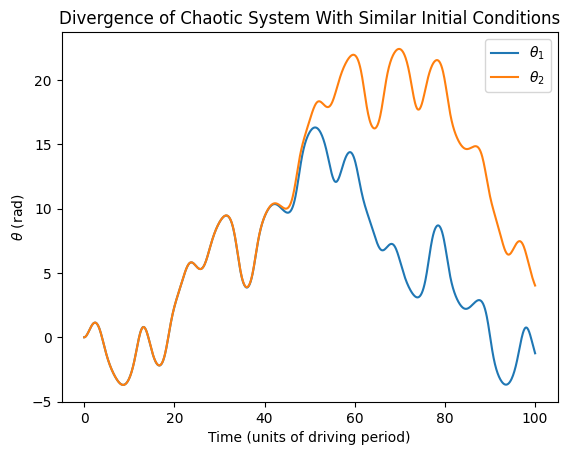

In [208]:
theta1 = sol_a.y[0]
theta2 = sol_b.y[0]

plt.plot(sol_a.t, theta1, label=r"$\theta_1$")
plt.plot(sol_b.t, theta2, label=r"$\theta_2$")

plt.title("Divergence of Chaotic System With Similar Initial Conditions")
plt.ylabel(r"$\theta$ (rad)")
plt.xlabel(r"Time (units of driving period)")

plt.legend()

plt.show()

(iii)

In [ ]:
Delta = np.log(np.abs(theta1 - theta2))

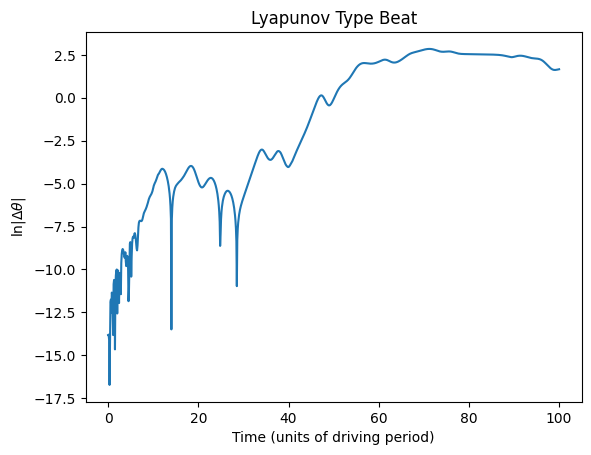

In [183]:
plt.plot(sol_a.t, Delta)

plt.title("Lyapunov Type Beat")
plt.ylabel(r"$\ln|\Delta \theta|$")
plt.xlabel(r"Time (units of driving period)")

plt.show()

The linear region looks roughly like its up to 10 driving periods.

In [199]:
end_idx = int(num_t*0.10)
st=20
fit_data = Delta[st:end_idx]

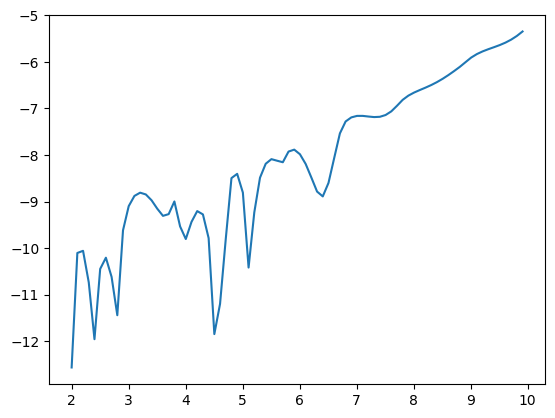

In [200]:
plt.plot(sol_a.t[st:end_idx], fit_data)

In [201]:
from scipy.stats import linregress

lyap = linregress(sol_a.t[st:end_idx], fit_data)
lyap[0]

np.float64(0.6898883950971524)

(iv) Lyapunov exponent is approximately $0.69$. Theoretically, we expect $\Delta = \Delta_0e^{\lambda t}$, so for a $\Delta_0 = 10^{-6}$ and $\Delta = 1$ we find
\begin{align*}
    1 &= 10^{-6}e^{\lambda t} \\
    0 &= -6\ln(10) + \lambda t \\
    t &= \frac{13.8}{\lambda} 
\end{align*}

With our $\lambda$ that's about $t = 20.02$, or twenty driving periods worth of time. The graph shows it taking a good bit longer than that, so its likely our calculation of $\lambda$ is a little bit off, but its pretty close for this sort of thing.

# Problem 3. Chaos in Double Pendulum

### *(a)* Deriving the Lagrangian

The coordinates of the first and second pendulum are:

\begin{align*}
    \begin{split}
        x_1 &=  \ell\sin\theta_1 \\
        y_1 &= -\ell\cos\theta_1
    \end{split}
    &
    &
    &
    \begin{split}
        x_2 &=  \ell\sin\theta_1 + \ell\sin\theta_2 \\
        y_2 &= -\ell\cos\theta_1 - \ell\cos\theta_2
    \end{split}
\end{align*}

And since we'll need the derivatives, we'll take a couple of those:
\begin{align*}
    \begin{split}
        \dot{x}_1 &=  \ell\dot\theta_1\cos\theta_1 \\
        \dot{y}_1 &=  \ell\dot\theta_1\sin\theta_1
    \end{split}
    &
    &
    &
    \begin{split}
        \dot{x}_2 &=  \ell\dot\theta_1\cos\theta_1 + \ell\dot\theta_2\cos\theta_2 \\
        \dot{y}_2 &=  \ell\dot\theta_1\sin\theta_1 + \ell\dot\theta_2\sin\theta_2
    \end{split}
\end{align*}

And the kinetic energy and potential energy are defined in the usual way, where $T = \frac{1}{2}m\vec{v}\cdot\vec{v}$ and $U = \sum_i mgy_i$

\begin{align*}
    T &= \frac{1}{2}m\left(\dot{x}_1^2 + \dot{y}_1^2 + \dot{x}_2^2 + \dot{y}_2^2\right) 
\end{align*}

For horizontal space reasons, we'll handle some of those terms separately:
\begin{align*}
    \dot{x}_1^2 + \dot{y}_1^2
    &= \ell^2 \dot\theta_1^2\cos^2\theta_1 + \ell^2 \dot\theta_1^2\sin^2\theta_2 = \ell^2\dot\theta_1^2
\end{align*}

\begin{align*}
    \dot{x}_2^2 
    &= \ell^2\dot\theta_1^2\cos^2\theta_1 + \ell^2\dot\theta_2^2\cos\theta_2 + 2\ell^2 \dot\theta_1\dot\theta_2\cos\theta_1\cos\theta_2 \\
     \dot{y}_2^2 
    &= \ell^2\dot\theta_1^2\sin^2\theta_1 + \ell^2\dot\theta_2^2\sin\theta_2 + 2\ell^2 \dot\theta_1\dot\theta_2\sin\theta_1\sin\theta_2 \\
    \dot{x}_2^2 + \dot{y}_2^2 
    &=
    \ell^2\dot\theta_1^2 + \ell^2\dot\theta_2^2 + 2\ell^2\dot\theta_1\dot\theta_2 \cos(\theta_1 - \theta_2)
\end{align*}

Where that bottom line uses $\cos x\cos y + \sin x \sin y = \cos(x - y)$


So the kinetic energy is then:
\begin{align*}
    T &= \frac{1}{2}m\ell^2 \left[\dot\theta_1^2 + \dot\theta_2^2 + \dot\theta_1\dot\theta_2\cos(\theta_1 - \theta_2)\right]
\end{align*}

The potential energy is then simply $U = - mg\ell\cos\theta_1 - mg\ell(\cos\theta_1 + \cos\theta_2)$, which makes Lagrangian
\begin{align*}
    \mathcal{L} &= \frac{1}{2}m\ell^2 \left[2\dot\theta_1^2 + \dot\theta_2^2 + 2\dot\theta_1\dot\theta_2\cos(\theta_1 - \theta_2)\right] + mg\ell\left(2\cos\theta_1 + \cos\theta_2\right)
\end{align*}

### *(b)* Euler-Lagrange

\begin{align*}
    \frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot{\theta}_1} &= \frac{\partial \mathcal{L}}{\partial \theta_1} \\
    \frac{d}{dt}\left[2m\ell^2\dot\theta_1 + m\ell^2\dot\theta_2\cos(\theta_1-\theta_2)\right]
    &= -m\ell^2\dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2) -2mg\ell\sin\theta_1 \\
    2\ddot{\theta}_1 + \ddot{\theta}_2\cos(\theta_1 - \theta_2) - \dot{\theta}_2(\dot{\theta}_1 - \dot\theta_2)\sin(\theta_1 - \theta_2) 
    &= -\dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2) -2\frac{g}{\ell}\sin\theta_1 \\
    2\ddot{\theta}_1 + \ddot{\theta}_2\cos(\theta_1 - \theta_2) + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{\ell}\sin\theta_1
    &= 0 
\end{align*}


\begin{align*}
    \frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot{\theta}_2} &= \frac{\partial \mathcal{L}}{\partial \theta_2} \\
    \frac{d}{dt}\left[m\ell^2\dot\theta_2 + m\ell^2\dot\theta_1\cos(\theta_1-\theta_2)\right]
    &= m\ell^2\dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2) - mg\ell\sin\theta_2 \\
    \ddot{\theta}_2 + \ddot{\theta}_1 \cos(\theta_1 - \theta_2) - \dot\theta_1(\dot\theta_1 - \dot\theta_2)\sin(\theta_1-\theta_2)
    &= \dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2) - \frac{g}{\ell}\sin\theta_2 \\
    \ddot{\theta}_2 + \ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{\ell}\sin\theta_2
    &= 0 
\end{align*}

### *(c)* Simulate double pendulum

This is the same problem as the take home exam so I'm just going to copy-paste the derivations and then modify the code from there... already did it once no reason to do it again.

We need to start by rearranging the equations of motion for $\ddot{\theta}_1$ and $\ddot{\theta}_2$

\begin{align*}
    2\ddot{\theta}_1 + \ddot{\theta}_2\cos(\theta_1 - \theta_2) + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1 &= 0 \\
    \ddot{\theta}_2  + \ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2 &= 0
\end{align*}
If we solve both of these for $\ddot{\theta}_2$, we get:
\begin{align*}
    \ddot{\theta}_2 &= \frac{-1}{\cos(\theta_1 - \theta_2)}\left[2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\right]\\
    \ddot{\theta}_2 &= -\left[\ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\right]
\end{align*}
And then we can set those equal to get:
\begin{align*}
    \frac{-1}{\cos(\theta_1 - \theta_2)}\left[2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\right]
    &=
    -\left[\ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\right] \\
    2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1 &=
    \ddot{\theta}_1\cos^2(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2)\cos(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\cos(\theta_1 - \theta_2) \\
    \ddot{\theta}_1\left[2-\cos^2(\theta_1 - \theta_2)\right] &= \frac{g}{l}\left[\cos(\theta_1 - \theta_2)\sin\theta_2 - 2\sin\theta_1\right] - \sin(\theta_1 - \theta_2)
    \left[\dot\theta_1^2\cos(\theta_1-\theta_2) + \dot\theta_2^2\right] \\
    \ddot{\theta}_1 &= \frac{\frac{g}{l}\left[\cos(\theta_1 - \theta_2)\sin\theta_2 - 2\sin\theta_1\right] - \sin(\theta_1 - \theta_2)
    \left[\dot\theta_1^2\cos(\theta_1-\theta_2) + \dot\theta_2^2\right]}{1 + \sin^2(\theta_1-\theta_2)}
\end{align*}

We can then go back and rearrange the first two equations for $\ddot{\theta}_1$ and solve for $\ddot{\theta}_2$
\begin{align*}
    \ddot{\theta}_1 &= -\frac{1}{2}\left[\ddot{\theta}_2\cos(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_1\right] \\
    \ddot{\theta}_1 &= \frac{-1}{\cos(\theta_1 - \theta_2)}\left[\ddot{\theta}_2 - \dot{\theta}_1^2\sin(\theta_1-\theta_2) + \frac{g}{l}\sin\theta_2\right]
\end{align*}
Setting those equal,
\begin{align*}
    -\frac{1}{2}\left[\ddot{\theta}_2\cos(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_1\right] &= 
    \frac{-1}{\cos(\theta_1 - \theta_2)}\left[\ddot{\theta}_2 - \dot{\theta}_1^2\sin(\theta_1-\theta_2) + \frac{g}{l}\sin\theta_2\right] \\
    \ddot{\theta}_2\cos^2(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2)\cos(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\cos(\theta_1 - \theta_2)
    &=
    2\ddot{\theta}_2 - 2\dot{\theta}_1^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_2 \\
    \ddot{\theta}_2 \left[\cos^2(\theta_1-\theta_2) - 2\right] &= -\sin(\theta_1-\theta_2)\left[2\dot{\theta}_1^2 + \dot{\theta}_2^2\cos(\theta_1-\theta_2)\right] + 2\frac{g}{l}\left[\sin\theta_2 - \cos(\theta_1-\theta_2)\sin\theta_1\right]\\
    \ddot{\theta}_2 &= \frac{\sin(\theta_1-\theta_2)\left[2\dot{\theta}_1^2 + \dot{\theta}_2^2\cos(\theta_1-\theta_2)\right] + 2\frac{g}{l}\left[\cos(\theta_1-\theta_2)\sin\theta_1 - \sin\theta_2\right]}{1+\sin^2(\theta_1-\theta_2)}
\end{align*}

Now we just write this coupled system of two second order equations as a couple system of four first order equations. That is, our ODE is basically of the form $\ddot{y} = \frac{d}{dt}F(\dot{y},t)$
\begin{align*}
    \begin{bmatrix}
        \ddot{\theta}_1 \\ \ddot{\theta}_2 \\ \dot{\theta}_1 \\ \dot{\theta}_2
    \end{bmatrix} 
    &=
    \frac{d}{dt} 
    \begin{bmatrix}
        \dot{\theta}_1 \\ \dot{\theta}_2 \\ \theta_1 \\ \theta_2
    \end{bmatrix}
    \to
    \begin{bmatrix}
        \dot{x}_1 \\ \dot x_2 \\ \dot x_3 \\ \dot x_4
    \end{bmatrix}
    &=
    \begin{bmatrix}
        \ddot{\theta}_1 \text{ equation } \\
        \ddot{\theta}_2 \text{ equation } \\
        x_1 \\
        x_2
    \end{bmatrix}
\end{align*}

In [202]:
g = 9.81
l = 1

def dbl_pend(t,y,g=g,l=l):
    d_theta_1, d_theta_2, theta_1, theta_2 = y
    delta_theta = theta_1 - theta_2

    denom = 1 + (np.sin(delta_theta))**2

    dd_theta_1 = (
        g/l * (np.cos(delta_theta)*np.sin(theta_2) - 2*np.sin(theta_1)) 
        - np.sin(delta_theta)*(d_theta_1**2*np.cos(delta_theta) + d_theta_2**2)
        ) / denom

    dd_theta_2 = (
        2*g/l * (np.cos(delta_theta)*np.sin(theta_1) - np.sin(theta_2) 
        + np.sin(delta_theta)*(2*d_theta_1**2 + d_theta_2**2*np.cos(delta_theta)))
        ) / denom

    return [dd_theta_1, dd_theta_2, d_theta_1, d_theta_2]

In [204]:
y0_sm = [0, 0, 0.1,0.1]
y0_lg = [0, 0, np.pi/2, np.pi/2]

sol_sm = solve_ivp(dbl_pend, [0,20], y0_sm, t_eval=np.linspace(0,20,1000))
sol_lg = solve_ivp(dbl_pend, [0,20], y0_lg, t_eval=np.linspace(0,20,1000))

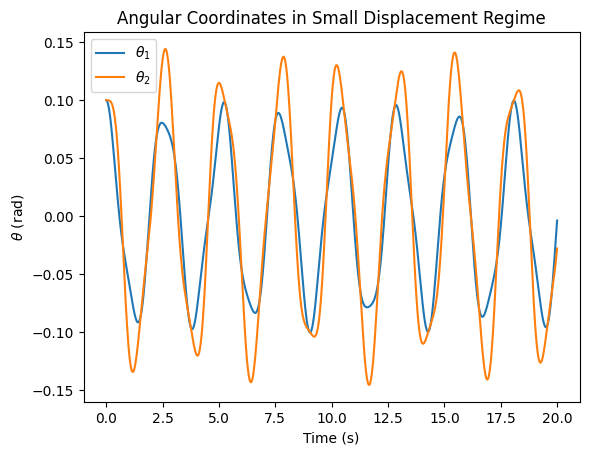

In [214]:
plt.plot(sol_sm.t, sol_sm.y[2], label=r"$\theta_1$")
plt.plot(sol_sm.t, sol_sm.y[3], label=r"$\theta_2$")

plt.title("Angular Coordinates in Small Displacement Regime")

plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)" )

plt.legend()

plt.show()

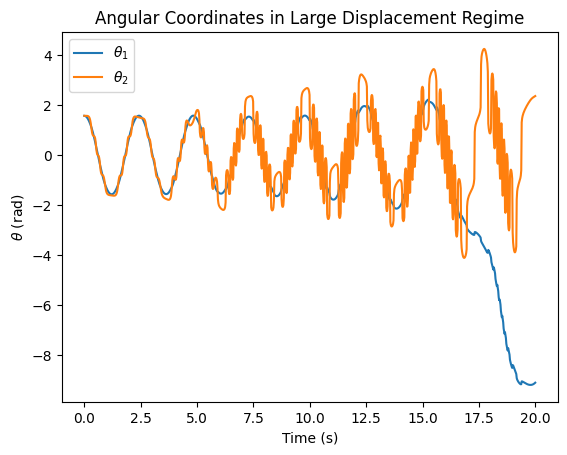

In [215]:
plt.plot(sol_lg.t, sol_lg.y[2], label=r"$\theta_1$")
plt.plot(sol_lg.t, sol_lg.y[3], label=r"$\theta_2$")

plt.title("Angular Coordinates in Large Displacement Regime")

plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)" )

plt.legend()

plt.show()

In the large displacement case, the second angle starts goin absolutely crazy, where the bottom mass stays quite a bit calmer in the small displacement case.

### *(d)* Chaos

(i) and also (ii)

In [229]:
y0_a = [0, 0, np.pi/2, np.pi/2]
y0_b = [0, 0, np.pi/2 + 1e-9, np.pi/2]

sol_a = solve_ivp(dbl_pend, [0,20], y0_a, t_eval=np.linspace(0,20,1000))
sol_b = solve_ivp(dbl_pend, [0,20], y0_b, t_eval=np.linspace(0,20,1000))

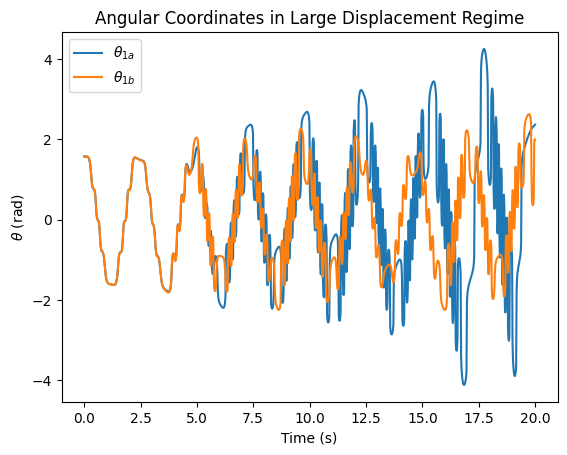

In [230]:
plt.plot(sol_a.t, sol_a.y[3], label=r"$\theta_{1a}$")
plt.plot(sol_b.t, sol_b.y[3], label=r"$\theta_{1b}$")

plt.title("Angular Coordinates in Large Displacement Regime")

plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)" )

plt.legend()

plt.show()

(iii) and also (iv)

In [231]:
theta1a = sol_a.y[2]
theta1b = sol_b.y[2]
theta2a = sol_a.y[3]
theta2b = sol_b.y[3]

Delta = np.log(np.sqrt((theta1a - theta1b)**2 + (theta2a - theta2b)**2))

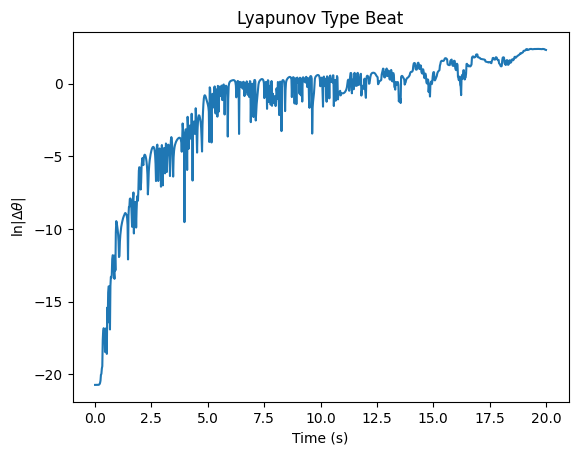

In [237]:
plt.plot(sol_a.t, Delta)

plt.title("Lyapunov Type Beat")
plt.ylabel(r"$\ln|\Delta \theta|$")
plt.xlabel(r"Time (s)")

plt.show()

In [238]:
end_idx = int(num_t*0.2)
st=1
fit_data = Delta[st:end_idx]

In [239]:
lyap = linregress(sol_a.t[st:end_idx], fit_data)
lyap[0]

np.float64(3.9354510514562606)

As before, the order of error reaches one (unpredictability) whenever the following is satisfied:
\begin{align*}
    \ln\Delta_0 + \lambda t = 0 \\
    t &= \frac{9\ln(10)}{3.935} = 5.27
\end{align*}

Which checks out if we go look at our graph, the two paths seem to diverge wildly after about 5 seconds.

(v) If instead the initial displacement was $10^{-3}$, the 9 in that equation above becomes a 3, so our answer is $1/3$ of the above, or about $1.75$ seconds (which makes sense, a larger initial difference means we have predictability for less time).